In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import csv
import json
import geopandas as gpd
import numpy as np

PD = 30
fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_farm_to_farm/'
shape_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
gdf = gpd.read_file(shape_file)


#### Generating one single csv file from simulations that were cut in half ####

In [3]:
# # averaging the results for the bigger simulations
# # for ID in [1, 6, 7, 8, 10, 12]:
# for ID in [11, 13]:
#     for year in [2012, 2013, 2017, 2018]:
#         file = 'simulation_farm_{}_June_September_{}_PD{}_connectivity.csv'.format(ID, year, PD)
#         # file1 = 'simulation_farm_{}_June_September_{}_{}_PD{}_connectivity.csv'.format(ID, year, 6, PD)
#         file1 = 'simulation_farm_{}_6_part_June_September_{}_{}_PD{}_connectivity.csv'.format(ID, year, 6, PD)
#         with open(fold+file1, mode='r', newline='', encoding='utf-8') as csvfile: 
#                 data1 = list(csv.DictReader(csvfile, delimiter=';'))
#         # file2 = 'simulation_farm_{}_June_September_{}_{}_PD{}_connectivity.csv'.format(ID, year, 7, PD)
#         file2 = 'simulation_farm_{}_6_part_June_September_{}_{}_PD{}_connectivity.csv'.format(ID, year, 7, PD)
#         with open(fold+file2, mode='r', newline='', encoding='utf-8') as csvfile: 
#                 data2 = list(csv.DictReader(csvfile, delimiter=';'))
#         data_mean = data1.copy()
        
#         for e2 in data2 :
#             i = 0
#             match = False
#             while i < len(data_mean) and not match:
#                 e_mean = data_mean[i]
#                 if e2['to'] == e_mean['to']: # if it is the same trajectory
#                     e_mean['N']=str(int(e_mean['N'])+int(e2['N'])) 
#                     match = True
#                 i+=1
#             if not match: # if the farm doesn't exist in the first file
#                 data_mean.append(e2)
#         for e in data_mean :
#             # calculate the new value of the probability of transport 
#             e['Ntot'] = str(int(e['Ntot'])*2)
#             e['prob'] = str(int(e['N'])/int(e['Ntot']))
        
#         with open(fold+file, "w", newline="") as file:
#             fieldnames = ["from", "to", "N", "Ntot", "prob"]
#             writer = csv.DictWriter(file, fieldnames=fieldnames, delimiter=';')
        
#             writer.writeheader()
#             writer.writerows(data_mean)

#### Node's locations ####

In [12]:
# Creating a dictionnary with the locations of the nodes
shpfile = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
shpfile_coast = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
poly = gpd.read_file(shpfile)
poly_coast = gpd.read_file(shpfile_coast)

loc = {}

for _, row in poly_coast.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    loc[str(row["ID"])] = (x, y)

for _, row in poly.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    loc[str(row["FarmID"])] = (x, y)

# loc = {1: (18.3, 60.9), 2:(17.5, 61.1), 3:(17.2, 61.3), 4:(17.7, 61.4), 5:(17.6, 61.7), 6:(18.2, 61.6), 7:(18.2, 62.2),
#        8:(18.8, 61), 9:(19, 61.3), 10:(18.5, 61.4), 11:(18.9, 61.8), 12:(19.5, 61.9), 13:(20, 60.6), 14: (21.1, 61.6),
#        15:(20.8, 61.7), 16:(20, 62), 17:(21, 61.9), 18:(20.8, 62.5), 19:(20.7, 62.7)}

with open(f"farm_locations.json", "w") as f:
    json.dump(loc, f)

## Creating Graphs ##

### From coast to coast ### 

In [14]:
# # Graph coast to coast (mean)
# PD = 60
# fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_coast_to_coast/'
# years = [2012, 2013, 2017, 2018]
# coastIDs = poly_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid

# G = nx.DiGraph()
# for year in years :
#     for ID in coastIDs:
        
#         file = f'simulation_coast_{ID}_June_September_{year}_PD{PD}_connectivity_to_coast.csv'
    
#         with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
#             reader = csv.DictReader(csvfile, delimiter=';')
    
#             for row in reader:
    
#                 origin = row['from']
#                 dest = row['to']
    
#                 attributes = {
#                     'N': float(row['N']),
#                     'prob': float(row['prob'])/len(years)
#                 }

#                 if (origin, dest) not in list(G.edges()):
#                     G.add_edge(origin, dest, **attributes)
#                 else :
#                     data = list(G.edges.data())
#                     G.edges[origin, dest]['N'] += attributes['N']
#                     G.edges[origin, dest]['prob'] += attributes['prob']

# # add node attributes
# for nd in G.nodes():

#     row = poly_coast.loc[poly_coast['ID'] == nd]

#     if not row.empty:
#         area = int(row.iloc[0]['Area_km2'])
#         G.nodes[nd]['area'] = area
# # save the graph as json file       
# data = nx.node_link_data(G)
# with open(f"Graph_json/Graph_mean_coast_to_coast_PD{PD}.json", "w") as f:
#     json.dump(data, f)

### From farm to farm ###

In [17]:
# # Graph farm to farm (mean)
# fold = f'/scratch/project_2018610/opendrift_outputs/simulation_15_part_per_km2/connectivity/PD{PD}/from_farm_to_farm/'
# years = [2012, 2013, 2017, 2018]
# farmIDs = np.arange(1, 20)

# G = nx.DiGraph()
# for year in years :
#     for ID in farmIDs:
    
#         file = f'simulation_farm_{ID}_June_September_{year}_connectivity.csv'
    
#         with open(fold+file, mode='r', newline='', encoding='utf-8') as csvfile:
#             reader = csv.DictReader(csvfile, delimiter=';')
    
#             for row in reader:
    
#                 origin = row['from']
#                 dest = row['to']
    
#                 attributes = {
#                     'N': float(row['N']),
#                     'prob': float(row['prob'])/len(years)
#                 }

#                 if (origin, dest) not in list(G.edges()):
#                     G.add_edge(origin, dest, **attributes)
#                 else :
#                     data = list(G.edges.data())
#                     G.edges[origin, dest]['N'] += attributes['N']
#                     G.edges[origin, dest]['prob'] += attributes['prob']

# # add node attributes
# for nd in G.nodes():

#     row = gdf.loc[gdf['FarmID'] == nd]

#     if not row.empty:
#         area = int(row.iloc[0]['Area_km2'])
#         G.nodes[nd]['area'] = area
# # save the graph as json file       
# data = nx.node_link_data(G)
# with open(f"Graph_mean_farm_to_farm_PD{PD}.json", "w") as f:
#     json.dump(data, f)

### Graph with everything (OWFs + coastal areas) ###

In [9]:
# open each json file and create a graph with the OWF and the coastal areas
# Seeding from coast
with open(f"Graph_json/Graph_mean_coast_to_coast_PD60.json", "r") as f:
    data = json.load(f)
G_c_to_c = nx.node_link_graph(data)

with open(f"Graph_json/Graph_mean_coast_to_farm_PD60.json", "r") as f:
    data = json.load(f)
G_c_to_f = nx.node_link_graph(data)
G_c = nx.compose(G_c_to_c, G_c_to_f)

# Seeding from farm
with open(f"Graph_json/Graph_mean_farm_to_coast_PD60.json", "r") as f:
    data = json.load(f)
G_f_to_c = nx.node_link_graph(data)

with open(f"Graph_json/Graph_mean_farm_to_farm_PD60.json", "r") as f:
    data = json.load(f)
G_f_to_f = nx.node_link_graph(data)
G_f = nx.compose(G_f_to_c, G_f_to_f)

G =nx.compose(G_f, G_c)
# save the graph as json file       
data = nx.node_link_data(G)
with open(f"Graph_json/Graph_mean_farm_and_coast_PD60.json", "w") as f:
    json.dump(data, f)

## Plotting graphs ##

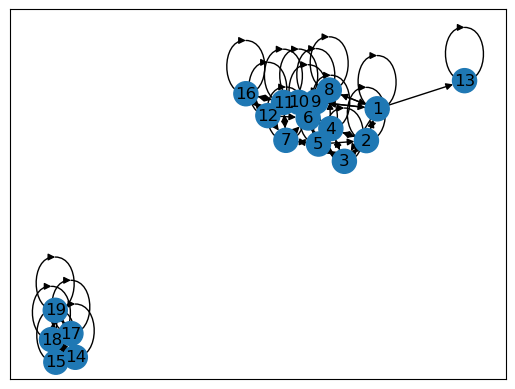

In [10]:
#Simpliest way to plot the graph
nx.display(G)

### Whole graph ###

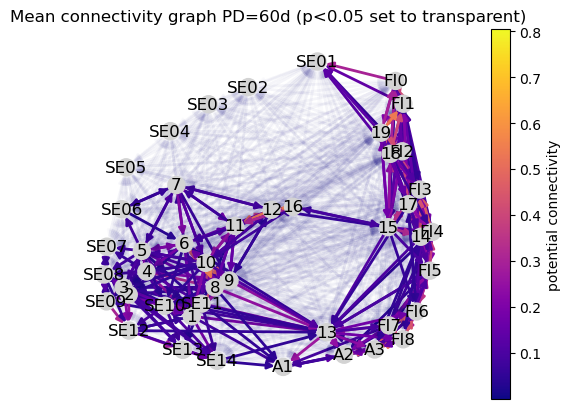

In [27]:
node_sizes = []
for nd in list(G.nodes()):
    if (nd, nd) in list(G.edges()):       
        G.remove_edge(nd, nd)
    size = 150 #+ G.nodes[nd]['area']
    node_sizes.append(size)
data = list(G.edges.data())
M = G.number_of_edges()
edge_colors = []
cmap = plt.cm.plasma

for i in range(M): 
    edge_colors.append(float(data[i][2]['prob']))

labels = nx.draw_networkx_labels(G, pos=loc)
nodes = nx.draw_networkx_nodes(G, pos=loc, node_size=node_sizes, node_color='lightgrey') #label=labels
edges = nx.draw_networkx_edges(
    G,
    pos=loc,
    label=False,
    arrows=True,
    arrowsize=10,
    node_size=node_sizes,
    edge_color=edge_colors,
    edge_cmap=cmap,
    width=2,
)

# set alpha value for each edge
limit = 0.05
for i in range(M):
    if data[i][2]['prob'] < limit:
        edges[i].set_alpha(0.02)
    else :
        edges[i].set_alpha(1)

pc = mpl.collections.PatchCollection(edges, cmap=cmap)
pc.set_array(edge_colors)
ax = plt.gca()
ax.set_axis_off()
#ax.set_title(f'Connectivity graph in {year} (probability<{limit} set to transparent)')
ax.set_title(f'Mean connectivity graph PD={PD}d (p<{limit} set to transparent)')
plt.colorbar(pc, ax=ax, label='potential connectivity')
#plt.savefig("connectivity_graph_{}_prob_{}.png".format(year, limit))
plt.savefig("connectivity_graphs/connectivity_graph_mean_farm_and_coast_prob_{}_PD{}.png".format(limit, PD))
plt.show()

### From coastal areas only ###

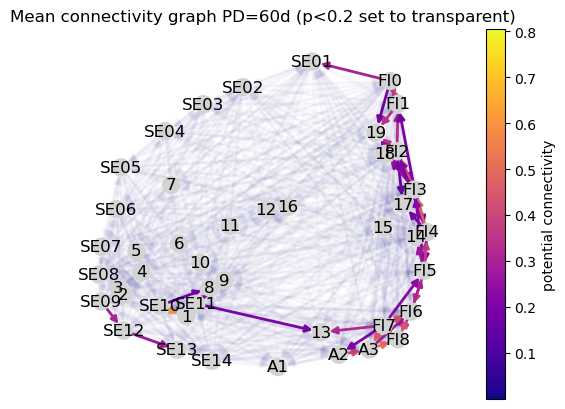

In [31]:
G = G_c.copy()
node_sizes = []
for nd in list(G.nodes()):
    if (nd, nd) in list(G.edges()):       
        G.remove_edge(nd, nd)
    size = 150 #+ G.nodes[nd]['area']
    node_sizes.append(size)
data = list(G.edges.data())
M = G.number_of_edges()
edge_colors = []
cmap = plt.cm.plasma

for i in range(M): 
    edge_colors.append(float(data[i][2]['prob']))

labels = nx.draw_networkx_labels(G, pos=loc)
nodes = nx.draw_networkx_nodes(G, pos=loc, node_size=node_sizes, node_color='lightgrey') #label=labels
edges = nx.draw_networkx_edges(
    G,
    pos=loc,
    label=False,
    arrows=True,
    arrowsize=10,
    node_size=node_sizes,
    edge_color=edge_colors,
    edge_cmap=cmap,
    width=2,
)

# set alpha value for each edge
limit = 0.2
for i in range(M):
    if data[i][2]['prob'] < limit:
        edges[i].set_alpha(0.02)
    else :
        edges[i].set_alpha(1)

pc = mpl.collections.PatchCollection(edges, cmap=cmap)
pc.set_array(edge_colors)
ax = plt.gca()
ax.set_axis_off()
#ax.set_title(f'Connectivity graph in {year} (probability<{limit} set to transparent)')
ax.set_title(f'Mean connectivity graph PD={PD}d (p<{limit} set to transparent)')
plt.colorbar(pc, ax=ax, label='potential connectivity')
#plt.savefig("connectivity_graph_{}_prob_{}.png".format(year, limit))
plt.savefig("connectivity_graphs/connectivity_graph_mean_coast_prob_{}_PD{}.png".format(limit, PD))
plt.show()

### From OWFs only ###

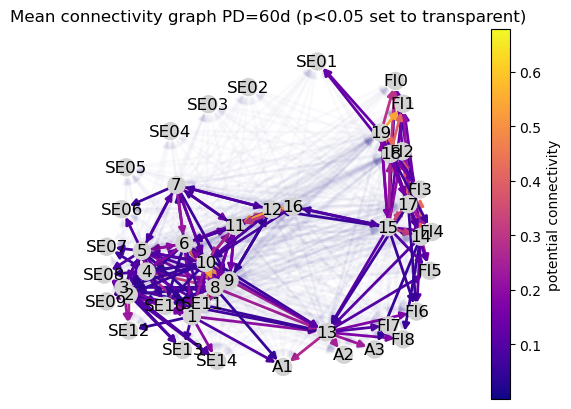

In [34]:
G = G_f.copy()
node_sizes = []
for nd in list(G.nodes()):
    if (nd, nd) in list(G.edges()):       
        G.remove_edge(nd, nd)
    size = 150 #+ G.nodes[nd]['area']
    node_sizes.append(size)
data = list(G.edges.data())
M = G.number_of_edges()
edge_colors = []
cmap = plt.cm.plasma

for i in range(M): 
    edge_colors.append(float(data[i][2]['prob']))

labels = nx.draw_networkx_labels(G, pos=loc)
nodes = nx.draw_networkx_nodes(G, pos=loc, node_size=node_sizes, node_color='lightgrey') #label=labels
edges = nx.draw_networkx_edges(
    G,
    pos=loc,
    label=False,
    arrows=True,
    arrowsize=10,
    node_size=node_sizes,
    edge_color=edge_colors,
    edge_cmap=cmap,
    width=2,
)

# set alpha value for each edge
limit = 0.05
for i in range(M):
    if data[i][2]['prob'] < limit:
        edges[i].set_alpha(0.02)
    else :
        edges[i].set_alpha(1)

pc = mpl.collections.PatchCollection(edges, cmap=cmap)
pc.set_array(edge_colors)
ax = plt.gca()
ax.set_axis_off()
#ax.set_title(f'Connectivity graph in {year} (probability<{limit} set to transparent)')
ax.set_title(f'Mean connectivity graph PD={PD}d (p<{limit} set to transparent)')
plt.colorbar(pc, ax=ax, label='potential connectivity')
#plt.savefig("connectivity_graph_{}_prob_{}.png".format(year, limit))
plt.savefig("connectivity_graphs/connectivity_graph_mean_farm_prob_{}_PD{}.png".format(limit, PD))
plt.show()